# 📊 Stack Overflow Developer Survey 2024
## Analyzing AI Tool Adoption Among Tech Professionals

**Author:** Diego Manzone  
**Dataset:** Stack Overflow Annual Developer Survey 2024  
**Goal:** Explore how technology professionals adopt AI tools based on 
their role, experience, and country.

---

In [25]:
# ── Data Manipulation ──────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualization ──────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── General Settings ───────────────────────────────────
pd.set_option("display.max_columns", 50)
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## 1. Data Loading & Initial Exploration

In this section we load the raw dataset and get a first look at its structure:
- Shape (rows and columns)
- Column names
- Data types
- Missing values overview

In [26]:
# ═══════════════════════════════════════════════════════════
# 📂 1.1 DATASET LOADING AND INITIAL STRUCTURE
# ═══════════════════════════════════════════════════════════

# Load main dataset
print("🔄 Loading dataset...")
df = pd.read_csv('survey_results_public.csv')

print("✅ Dataset loaded successfully!\n")
print("=" * 60)
print("📊 BASIC DATASET INFORMATION")
print("=" * 60)

# Basic dataset information
print(f"📏 Dataset dimensions: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print(f"💾 Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print(f"📅 Unique data types: {df.dtypes.value_counts().to_dict()}")

# First rows of the dataset
print("\n" + "=" * 60)
print("👀 DATASET PREVIEW")  
print("=" * 60)
display(df.head())

🔄 Loading dataset...
✅ Dataset loaded successfully!

📊 BASIC DATASET INFORMATION
📏 Dataset dimensions: 65,437 rows × 114 columns
💾 Memory usage: 450.5 MB
📅 Unique data types: {dtype('O'): 100, dtype('float64'): 13, dtype('int64'): 1}

👀 DATASET PREVIEW


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,TechDoc,YearsCode,YearsCodePro,DevType,OrgSize,PurchaseInfluence,BuyNewTool,BuildvsBuy,TechEndorse,Country,Currency,CompTotal,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,...,Knowledge_8,Knowledge_9,Frequency_1,Frequency_2,Frequency_3,TimeSearching,TimeAnswering,Frustration,ProfessionalTech,ProfessionalCloud,ProfessionalQuestion,Industry,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,United States of America,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,20,17,"Developer, full-stack",NaN,NaN,NaN,NaN,NaN,United Kingdom of Great Britain and Northern I...,NaN,NaN,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,...,Agree,Agree,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,API document(s) and/or SDK document(s);User gu...,37,27,Developer Experience,NaN,NaN,NaN,NaN,NaN,United Kingdom of Great Britain and Northern I...,NaN,NaN,C#,C#,C#,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,NaN,4,NaN,"Developer, full-stack",NaN,NaN,NaN,NaN,NaN,Canada,NaN,NaN,C;C++;HTML/CSS;Java;JavaScript;PHP;PowerShell;...,HTML/CSS;Java;JavaScript;PowerShell;Python;SQL...,HTML/CSS;Java;JavaScript;PowerShell;Python;SQL...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,API document(s) and/or SDK document(s);User gu...,9,NaN,"Developer, full-stack",NaN,NaN,NaN,NaN,NaN,Norway,NaN,NaN,C++;HTML/CSS;JavaScript;Lua;Python;Rust,C++;HTML/CSS;JavaScript;Lua;Python,C++;HTML/CSS;JavaScript;Lua;Python,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


In [27]:
ai_cols = [col for col in df.columns if 'AI' in col or 'ai' in col.lower()]
print(ai_cols)

['MainBranch', 'AISearchDevHaveWorkedWith', 'AISearchDevWantToWorkWith', 'AISearchDevAdmired', 'AISelect', 'AISent', 'AIBen', 'AIAcc', 'AIComplex', 'AIToolCurrently Using', 'AIToolInterested in Using', 'AIToolNot interested in Using', 'AINextMuch more integrated', 'AINextNo change', 'AINextMore integrated', 'AINextLess integrated', 'AINextMuch less integrated', 'AIThreat', 'AIEthics', 'AIChallenges']


In [28]:
# ═══════════════════════════════════════════════════════════
# 🔍 1.2 DETAILED DATASET INFORMATION
# ═══════════════════════════════════════════════════════════

print("=" * 60)
print("📋 DETAILED DATASET STRUCTURE")
print("=" * 60)

# Comprehensive dataset info
df.info(memory_usage='deep')

print("\n" + "=" * 60)
print("📊 DATA TYPES SUMMARY")
print("=" * 60)

# Data types breakdown
dtype_summary = df.dtypes.value_counts()
print("\nData Type Distribution:")
for dtype, count in dtype_summary.items():
    percentage = (count / len(df.columns)) * 100
    print(f"  • {dtype}: {count} columns ({percentage:.1f}%)")

print(f"\nTotal Columns: {len(df.columns)}")

📋 DETAILED DATASET STRUCTURE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65437 entries, 0 to 65436
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), object(100)
memory usage: 450.5 MB

📊 DATA TYPES SUMMARY

Data Type Distribution:
  • object: 100 columns (87.7%)
  • float64: 13 columns (11.4%)
  • int64: 1 columns (0.9%)

Total Columns: 114


🔍 MISSING VALUES ASSESSMENT
📊 Columns with missing values: 109 out of 114 total columns
📉 Missing data percentage: 95.6%

🔝 TOP 15 COLUMNS WITH MISSING VALUES:
--------------------------------------------------
  • AINextMuch less integrated    : 64,289 ( 98.2%)
  • AINextLess integrated         : 63,082 ( 96.4%)
  • AINextNo change               : 52,939 ( 80.9%)
  • AINextMuch more integrated    : 51,999 ( 79.5%)
  • EmbeddedAdmired               : 48,704 ( 74.4%)
  • EmbeddedWantToWorkWith        : 47,837 ( 73.1%)
  • EmbeddedHaveWorkedWith        : 43,223 ( 66.1%)
  • ConvertedCompYearly           : 42,002 ( 64.2%)
  • AIToolNot interested in Using : 41,023 ( 62.7%)
  • AINextMore integrated         : 41,009 ( 62.7%)
  • Knowledge_9                   : 37,802 ( 57.8%)
  • Frequency_3                   : 37,727 ( 57.7%)
  • Knowledge_8                   : 37,679 ( 57.6%)
  • ProfessionalTech              : 37,673 ( 57.6%)
  • Knowledge_7                   : 37,659 ( 57.6%)

📈 MISSIN

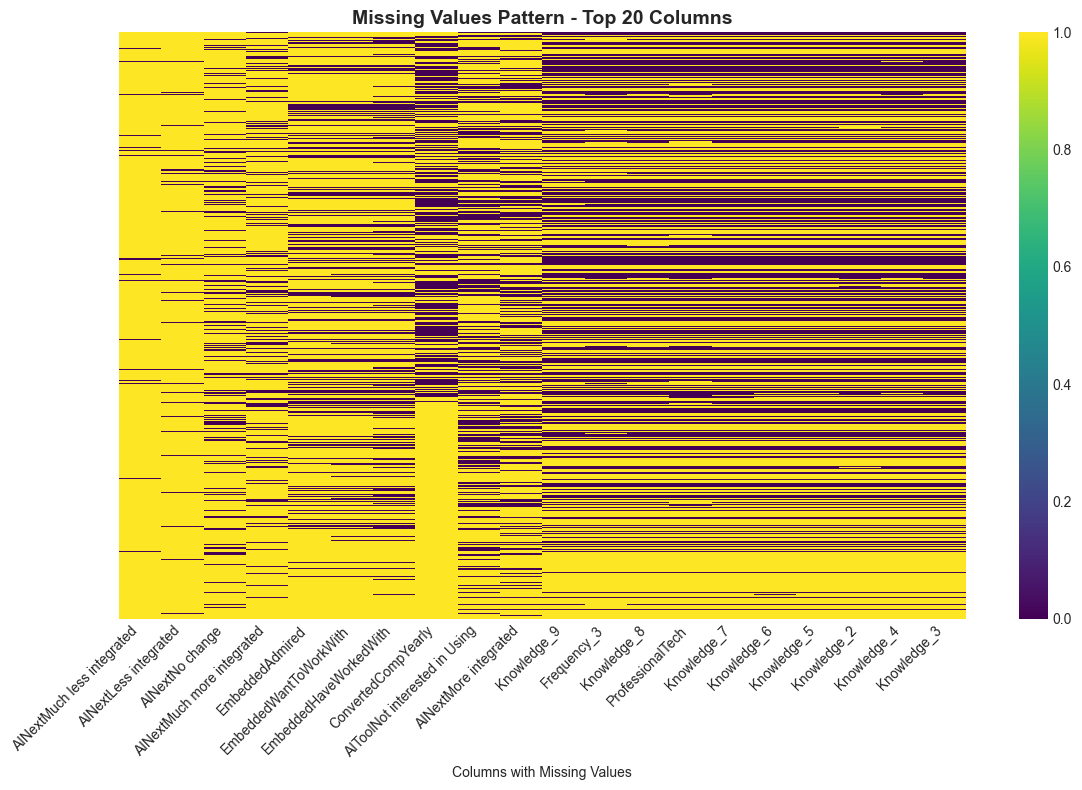

In [29]:
# ═══════════════════════════════════════════════════════════
# 🚫 1.3 MISSING VALUES ANALYSIS
# ═══════════════════════════════════════════════════════════

print("=" * 60)
print("🔍 MISSING VALUES ASSESSMENT")
print("=" * 60)

# Calculate missing values
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

if len(missing_data) > 0:
    print(f"📊 Columns with missing values: {len(missing_data)} out of {len(df.columns)} total columns")
    print(f"📉 Missing data percentage: {len(missing_data)/len(df.columns)*100:.1f}%\n")
    
    # Top 15 columns with most missing values
    print("🔝 TOP 15 COLUMNS WITH MISSING VALUES:")
    print("-" * 50)
    top_missing = missing_data.head(15)
    
    for col, count in top_missing.items():
        percentage = (count / len(df)) * 100
        print(f"  • {col:<30}: {count:>6,} ({percentage:>5.1f}%)")
    
    # Summary statistics
    total_missing = missing_data.sum()
    total_cells = len(df) * len(df.columns)
    
    print(f"\n📈 MISSING DATA SUMMARY:")
    print(f"  • Total missing values: {total_missing:,}")
    print(f"  • Total cells: {total_cells:,}")
    print(f"  • Overall missing percentage: {(total_missing/total_cells)*100:.2f}%")
    
else:
    print("✅ No missing values found in the dataset!")

# Create a visualization of missing values pattern
print("\n" + "=" * 60)
print("📊 MISSING VALUES VISUALIZATION")
print("=" * 60)

# Missing values heatmap for top columns
if len(missing_data) > 0:
    top_missing_cols = missing_data.head(20).index
    
    plt.figure(figsize=(12, 8))
    sns.heatmap(df[top_missing_cols].isnull(), 
                yticklabels=False, 
                cbar=True, 
                cmap='viridis')
    plt.title('Missing Values Pattern - Top 20 Columns', fontsize=14, fontweight='bold')
    plt.xlabel('Columns with Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [30]:
# ═══════════════════════════════════════════════════════════
# 🎯 1.4 KEY VARIABLES IDENTIFICATION
# ═══════════════════════════════════════════════════════════

print("=" * 60)
print("🔍 IDENTIFYING KEY VARIABLES FOR ANALYSIS")
print("=" * 60)

# Define priority variables based on our research objectives
ai_variables = ['AISelect', 'AISent', 'AIBen', 'AIThreat', 'AIAcc']
professional_variables = ['DevType', 'YearsCode', 'Employment', 'WorkExp', 'OrgSize']
demographic_variables = ['Country', 'Age', 'EdLevel', 'Gender', 'Ethnicity']
compensation_variables = ['CompTotal', 'CompFreq', 'Currency']

all_priority_vars = ai_variables + professional_variables + demographic_variables + compensation_variables

# Check which variables exist in our dataset
print("🤖 AI-RELATED VARIABLES:")
existing_ai_vars = []
for var in ai_variables:
    if var in df.columns:
        existing_ai_vars.append(var)
        print(f"  ✅ {var}")
    else:
        print(f"  ❌ {var} (not found)")

print(f"\n👨‍💻 PROFESSIONAL VARIABLES:")
existing_prof_vars = []
for var in professional_variables:
    if var in df.columns:
        existing_prof_vars.append(var)
        print(f"  ✅ {var}")
    else:
        print(f"  ❌ {var} (not found)")

print(f"\n🌍 DEMOGRAPHIC VARIABLES:")
existing_demo_vars = []
for var in demographic_variables:
    if var in df.columns:
        existing_demo_vars.append(var)
        print(f"  ✅ {var}")
    else:
        print(f"  ❌ {var} (not found)")

print(f"\n💰 COMPENSATION VARIABLES:")
existing_comp_vars = []
for var in compensation_variables:
    if var in df.columns:
        existing_comp_vars.append(var)
        print(f"  ✅ {var}")
    else:
        print(f"  ❌ {var} (not found)")

# Create a list of all existing priority variables
existing_priority_vars = existing_ai_vars + existing_prof_vars + existing_demo_vars + existing_comp_vars

print(f"\n📋 SUMMARY:")
print(f"  • Total priority variables identified: {len(existing_priority_vars)}")
print(f"  • AI variables available: {len(existing_ai_vars)}")
print(f"  • Professional variables available: {len(existing_prof_vars)}")
print(f"  • Demographic variables available: {len(existing_demo_vars)}")
print(f"  • Compensation variables available: {len(existing_comp_vars)}")

# Show all available columns for reference (first 20)
print(f"\n📋 AVAILABLE COLUMNS (showing first 20 of {len(df.columns)}):")
for i, col in enumerate(df.columns[:20]):
    print(f"  {i+1:2d}. {col}")
if len(df.columns) > 20:
    print(f"  ... and {len(df.columns) - 20} more columns")

🔍 IDENTIFYING KEY VARIABLES FOR ANALYSIS
🤖 AI-RELATED VARIABLES:
  ✅ AISelect
  ✅ AISent
  ✅ AIBen
  ✅ AIThreat
  ✅ AIAcc

👨‍💻 PROFESSIONAL VARIABLES:
  ✅ DevType
  ✅ YearsCode
  ✅ Employment
  ✅ WorkExp
  ✅ OrgSize

🌍 DEMOGRAPHIC VARIABLES:
  ✅ Country
  ✅ Age
  ✅ EdLevel
  ❌ Gender (not found)
  ❌ Ethnicity (not found)

💰 COMPENSATION VARIABLES:
  ✅ CompTotal
  ❌ CompFreq (not found)
  ✅ Currency

📋 SUMMARY:
  • Total priority variables identified: 15
  • AI variables available: 5
  • Professional variables available: 5
  • Demographic variables available: 3
  • Compensation variables available: 2

📋 AVAILABLE COLUMNS (showing first 20 of 114):
   1. ResponseId
   2. MainBranch
   3. Age
   4. Employment
   5. RemoteWork
   6. Check
   7. CodingActivities
   8. EdLevel
   9. LearnCode
  10. LearnCodeOnline
  11. TechDoc
  12. YearsCode
  13. YearsCodePro
  14. DevType
  15. OrgSize
  16. PurchaseInfluence
  17. BuyNewTool
  18. BuildvsBuy
  19. TechEndorse
  20. Country
  ... and 94 

In [31]:
# ═══════════════════════════════════════════════════════════
# 📈 1.5 INITIAL EDA SUMMARY & DATASET HEALTH CHECK
# ═══════════════════════════════════════════════════════════

print("=" * 60)
print("📋 DATASET HEALTH ASSESSMENT")
print("=" * 60)

# Dataset quality metrics
total_rows = len(df)
total_cols = len(df.columns)
memory_usage_mb = df.memory_usage(deep=True).sum() / 1024**2

# Missing values assessment
total_missing = df.isnull().sum().sum()
total_cells = total_rows * total_cols
missing_percentage = (total_missing / total_cells) * 100

# Data completeness by variable type
numeric_cols = df.select_dtypes(include=[np.number]).columns
categorical_cols = df.select_dtypes(include=['object']).columns
datetime_cols = df.select_dtypes(include=['datetime64']).columns

# Check for duplicates
duplicate_rows = df.duplicated().sum()

print("🏥 DATASET HEALTH METRICS:")
print(f"  • Dataset size: {total_rows:,} rows × {total_cols:,} columns")
print(f"  • Memory usage: {memory_usage_mb:.1f} MB")
print(f"  • Data completeness: {100-missing_percentage:.1f}%")
print(f"  • Missing values: {total_missing:,} ({missing_percentage:.2f}%)")
print(f"  • Duplicate rows: {duplicate_rows:,}")

print(f"\n📊 COLUMN TYPE BREAKDOWN:")
print(f"  • Numeric columns: {len(numeric_cols)}")
print(f"  • Categorical columns: {len(categorical_cols)}")
print(f"  • Datetime columns: {len(datetime_cols)}")

# Sample of categorical variables with their unique values
print(f"\n🏷️  CATEGORICAL VARIABLES SAMPLE:")
if len(categorical_cols) > 0:
    for col in categorical_cols[:5]:  # Show first 5 categorical columns
        unique_count = df[col].nunique()
        print(f"  • {col}: {unique_count} unique values")
        if unique_count <= 10:  # Show values if few unique values
            print(f"    Values: {df[col].value_counts().head(3).index.tolist()[:3]}")

# Quality assessment
print(f"\n✅ DATA QUALITY ASSESSMENT:")
if missing_percentage < 10:
    print("  • Missing data: ✅ GOOD (< 10%)")
elif missing_percentage < 25:
    print("  • Missing data: ⚠️  MODERATE (10-25%)")
else:
    print("  • Missing data: ❌ HIGH (> 25%)")

if duplicate_rows == 0:
    print("  • Duplicates: ✅ NONE FOUND")
elif duplicate_rows < total_rows * 0.01:
    print("  • Duplicates: ⚠️  MINIMAL (< 1%)")
else:
    print("  • Duplicates: ❌ SIGNIFICANT (> 1%)")

if memory_usage_mb < 100:
    print("  • Memory usage: ✅ EFFICIENT (< 100 MB)")
elif memory_usage_mb < 500:
    print("  • Memory usage: ⚠️  MODERATE (100-500 MB)")
else:
    print("  • Memory usage: ❌ HIGH (> 500 MB)")

print(f"\n🎯 NEXT STEPS:")
print("  1. 📊 Conduct univariate analysis of key variables")
print("  2. 🔗 Explore relationships between AI adoption and demographics")
print("  3. 🌍 Analyze geographical patterns in survey responses")
print("  4. 💼 Investigate professional experience vs AI sentiment")
print("  5. 📈 Build predictive models for AI adoption")

print("\n" + "=" * 60)
print("✅ INITIAL EDA COMPLETED SUCCESSFULLY!")
print("=" * 60)

📋 DATASET HEALTH ASSESSMENT
🏥 DATASET HEALTH METRICS:
  • Dataset size: 65,437 rows × 114 columns
  • Memory usage: 450.5 MB
  • Data completeness: 61.2%
  • Missing values: 2,890,957 (38.75%)
  • Duplicate rows: 0

📊 COLUMN TYPE BREAKDOWN:
  • Numeric columns: 14
  • Categorical columns: 100
  • Datetime columns: 0

🏷️  CATEGORICAL VARIABLES SAMPLE:
  • MainBranch: 5 unique values
    Values: ['I am a developer by profession', 'I am not primarily a developer, but I write code sometimes as part of my work/studies', 'I am learning to code']
  • Age: 8 unique values
    Values: ['25-34 years old', '35-44 years old', '18-24 years old']
  • Employment: 110 unique values
  • RemoteWork: 3 unique values
    Values: ['Hybrid (some remote, some in-person)', 'Remote', 'In-person']
  • Check: 1 unique values
    Values: ['Apples']

✅ DATA QUALITY ASSESSMENT:
  • Missing data: ❌ HIGH (> 25%)
  • Duplicates: ✅ NONE FOUND
  • Memory usage: ⚠️  MODERATE (100-500 MB)

🎯 NEXT STEPS:
  1. 📊 Conduct uni

👥 AGE GROUPS (Age)
Number of age groups: 8

Age
25-34 years old       23911
35-44 years old       14942
18-24 years old       14098
45-54 years old        6249
55-64 years old        2575
Under 18 years old     2568
65 years or older       772
Prefer not to say       322

🌍 PARTICIPATING COUNTRIES (Country)
Number of unique countries: 185

Top 15 countries by responses:
Country
United States of America                                11095
Germany                                                  4947
India                                                    4231
United Kingdom of Great Britain and Northern Ireland     3224
Ukraine                                                  2672
France                                                   2110
Canada                                                   2104
Poland                                                   1534
Netherlands                                              1449
Brazil                                                   1375

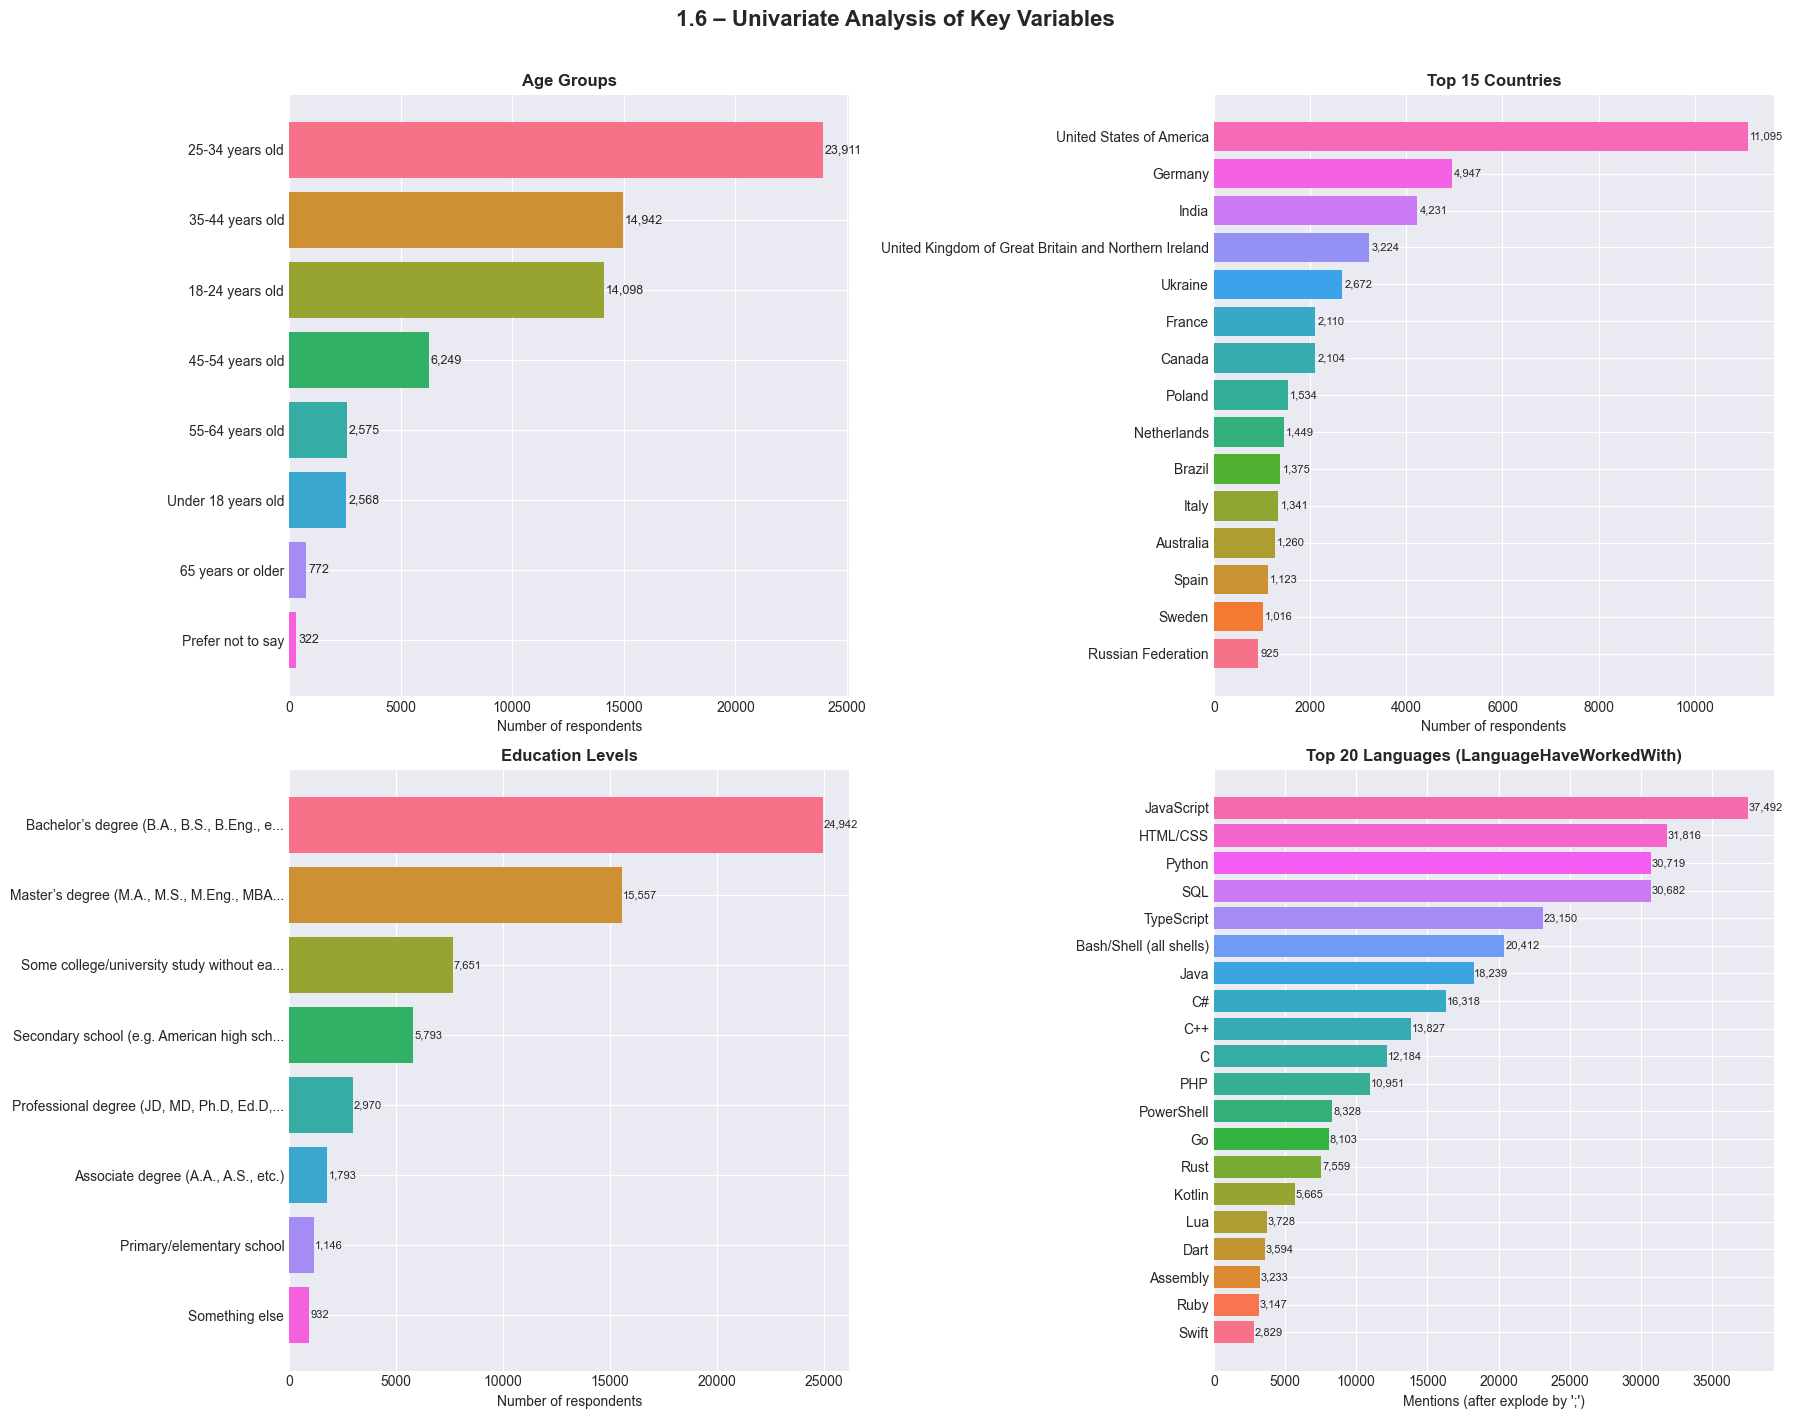


✅ Section 1.6 completed.


In [32]:
# ═══════════════════════════════════════════════════════════
# 📊 1.6 UNIVARIATE ANALYSIS – Age, Country, EdLevel, Languages
# ═══════════════════════════════════════════════════════════

# ── 1. AGE GROUPS ───────────────────────────────────────────
print("=" * 60)
print("👥 AGE GROUPS (Age)")
print("=" * 60)
age_counts = df["Age"].value_counts()
print(f"Number of age groups: {df['Age'].nunique()}\n")
print(age_counts.to_string())

# ── 2. COUNTRIES ────────────────────────────────────────────
print("\n" + "=" * 60)
print("🌍 PARTICIPATING COUNTRIES (Country)")
print("=" * 60)
print(f"Number of unique countries: {df['Country'].nunique()}\n")
print("Top 15 countries by responses:")
print(df["Country"].value_counts().head(15).to_string())

# ── 3. EDUCATION LEVEL ──────────────────────────────────────
print("\n" + "=" * 60)
print("🎓 EDUCATION LEVELS (EdLevel)")
print("=" * 60)
ed_counts = df["EdLevel"].value_counts()
print(f"Number of levels: {df['EdLevel'].nunique()}\n")
print(ed_counts.to_string())

# ── 4. LANGUAGES (with explode) ──────────────────────────────
print("\n" + "=" * 60)
print("💻 LANGUAGES (LanguageHaveWorkedWith) — split by ';' and exploded")
print("=" * 60)

# Split by ";" and explode: each language gets its own row
lang_series = (
    df["LanguageHaveWorkedWith"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
)

lang_counts = lang_series.value_counts()
print(f"Number of unique languages: {lang_counts.shape[0]}\n")
print("Top 20 most used languages:")
print(lang_counts.head(20).to_string())

# ── VISUALIZATIONS ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle("1.6 – Univariate Analysis of Key Variables", fontsize=16, fontweight="bold", y=1.01)

# --- Age ---
ax = axes[0, 0]
age_order = age_counts.sort_values(ascending=False).index
bars = ax.barh(age_order, age_counts[age_order], color=sns.color_palette("husl", len(age_order)))
ax.set_title("Age Groups", fontweight="bold")
ax.set_xlabel("Number of respondents")
for bar in bars:
    ax.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
            f"{int(bar.get_width()):,}", va="center", fontsize=9)
ax.invert_yaxis()

# --- Countries (top 15) ---
ax = axes[0, 1]
top_countries = df["Country"].value_counts().head(15)
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1],
               color=sns.color_palette("husl", 15))
ax.set_title("Top 15 Countries", fontweight="bold")
ax.set_xlabel("Number of respondents")
for bar in bars:
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f"{int(bar.get_width()):,}", va="center", fontsize=8)

# --- EdLevel ---
ax = axes[1, 0]
ed_order = ed_counts.sort_values(ascending=False).index
# Truncate long labels
ed_labels = [label[:40] + "..." if len(label) > 40 else label for label in ed_order]
bars = ax.barh(ed_labels, ed_counts[ed_order], color=sns.color_palette("husl", len(ed_order)))
ax.set_title("Education Levels", fontweight="bold")
ax.set_xlabel("Number of respondents")
for bar in bars:
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f"{int(bar.get_width()):,}", va="center", fontsize=8)
ax.invert_yaxis()

# --- Languages (top 20) ---
ax = axes[1, 1]
top_langs = lang_counts.head(20)
bars = ax.barh(top_langs.index[::-1], top_langs.values[::-1],
               color=sns.color_palette("husl", 20))
ax.set_title("Top 20 Languages (LanguageHaveWorkedWith)", fontweight="bold")
ax.set_xlabel("Mentions (after explode by ';')")
for bar in bars:
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f"{int(bar.get_width()):,}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

print("\n✅ Section 1.6 completed.")

🤖 AI ADOPTION & SENTIMENT – OVERVIEW

📌 AISelect — Do you currently use AI tools in your development process?
Valid responses: 60,907 (93.1% of total)

  • Yes                                                           61.8%
  • No, and I don't plan to                                       24.4%
  • No, but I plan to soon                                        13.8%

📌 AISent — What is your general sentiment toward AI tools?
Valid responses: 45,873 (70.1% of total)

  • Favorable                                                     48.3%
  • Very favorable                                                23.6%
  • Indifferent                                                   18.7%
  • Unfavorable                                                    5.2%
  • Unsure                                                         3.0%
  • Very unfavorable                                               1.2%

📌 AIBen — What AI tool do you consider most beneficial?
Valid responses: 36,894 (56.4% of total)


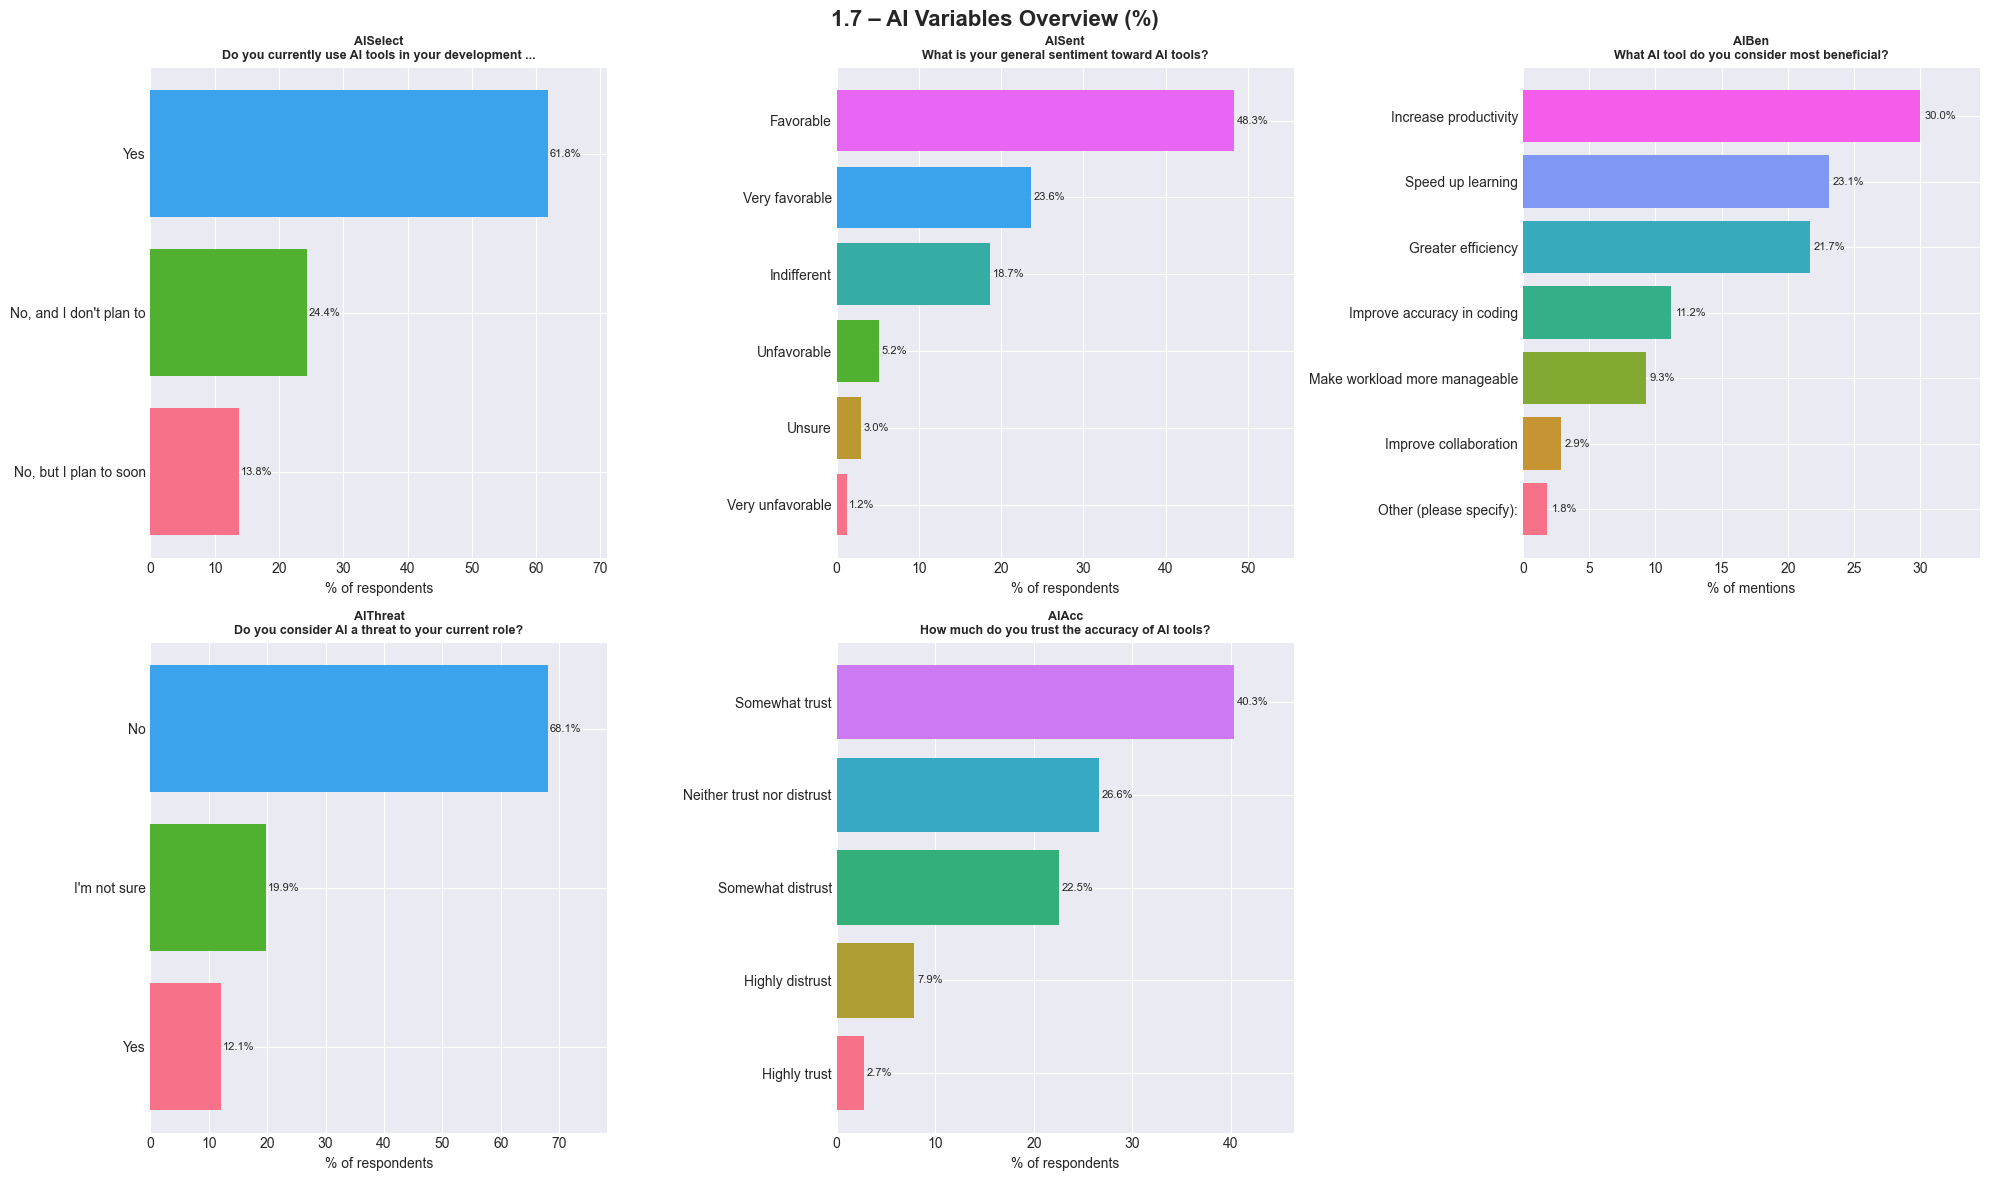


✅ Section 1.7 completed.


In [33]:
# ═══════════════════════════════════════════════════════════
# 🤖 1.7 AI VARIABLES OVERVIEW
# ═══════════════════════════════════════════════════════════

print("=" * 60)
print("🤖 AI ADOPTION & SENTIMENT – OVERVIEW")
print("=" * 60)

ai_vars = {
    "AISelect":  "Do you currently use AI tools in your development process?",
    "AISent":    "What is your general sentiment toward AI tools?",
    "AIBen":     "What AI tool do you consider most beneficial?",
    "AIThreat":  "Do you consider AI a threat to your current role?",
    "AIAcc":     "How much do you trust the accuracy of AI tools?"
}

# ── Print distributions ──────────────────────────────────────
for col, description in ai_vars.items():
    print(f"\n{'=' * 60}")
    print(f"📌 {col} — {description}")
    print(f"{'=' * 60}")
    counts = df[col].value_counts(dropna=True)
    total_valid = counts.sum()
    print(f"Valid responses: {total_valid:,} ({total_valid/len(df)*100:.1f}% of total)\n")
    for val, cnt in counts.items():
        pct = cnt / total_valid * 100
        label = str(val)[:60]
        print(f"  • {label:<60} {pct:>5.1f}%")

# ── AIBen: explode multi-response ───────────────────────────
aiben_counts = (
    df["AIBen"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)
aiben_pct = aiben_counts / aiben_counts.sum() * 100

# ── VISUALIZATIONS ───────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("1.7 – AI Variables Overview (%)", fontsize=16, fontweight="bold")

axes_flat = axes.flatten()
axes_flat[-1].set_visible(False)

for i, (col, description) in enumerate(ai_vars.items()):
    ax = axes_flat[i]

    if col == "AIBen":
        pct_values = aiben_pct
        xlabel = "% of mentions"
    else:
        counts = df[col].value_counts(dropna=True)
        pct_values = counts / counts.sum() * 100
        xlabel = "% of respondents"

    labels = [str(l)[:35] + "..." if len(str(l)) > 35 else str(l) for l in pct_values.index]

    bars = ax.barh(labels[::-1], pct_values.values[::-1],
                   color=sns.color_palette("husl", len(pct_values)))
    ax.set_title(f"{col}\n{description[:50] + '...' if len(description) > 50 else description}",
                 fontsize=9, fontweight="bold")
    ax.set_xlabel(xlabel)
    ax.set_xlim(0, pct_values.max() * 1.15)

    for bar in bars:
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
                f"{bar.get_width():.1f}%", va="center", fontsize=8)

plt.tight_layout()
plt.show()

print("\n✅ Section 1.7 completed.")

📊 1.8 – AI ADOPTION BY AGE (AISelect)
AISelect          Yes  No, but I plan to soon  No, and I don't plan to
Age                                                                   
18-24 years old  70.4                     8.8                     20.8
25-34 years old  65.6                    13.0                     21.5
35-44 years old  57.9                    16.1                     25.9


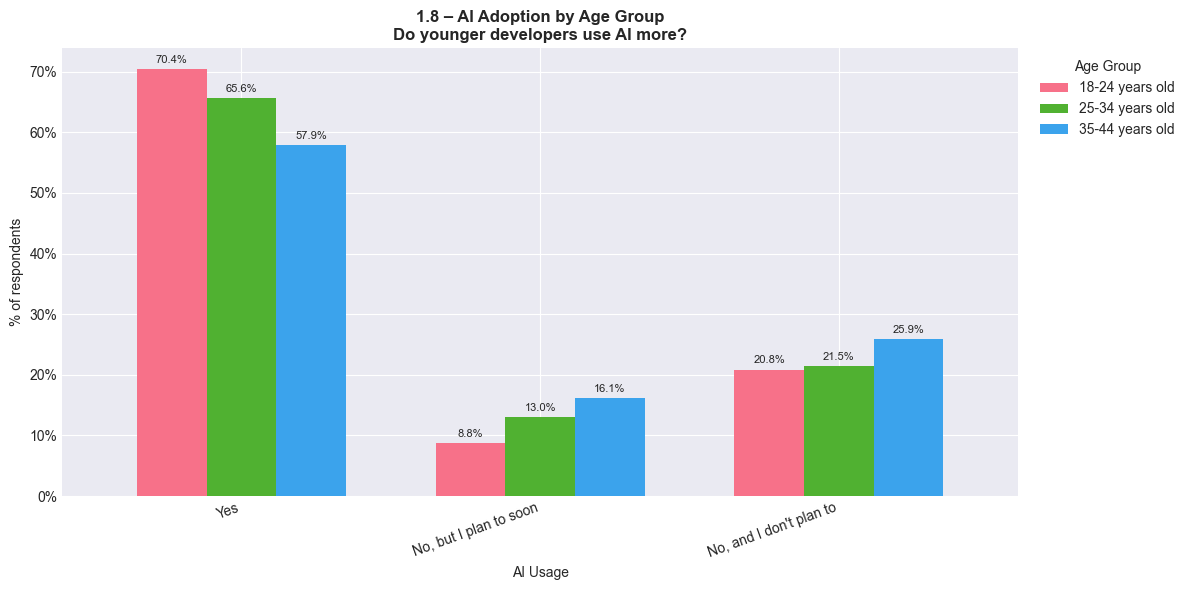


✅ Section 1.8 completed.


In [34]:
# ── Filter top 3 age groups ──────────────────────────────────
top_ages = ["25-34 years old", "35-44 years old", "18-24 years old"]
df_ages = df[df["Age"].isin(top_ages)].copy()

# ═══════════════════════════════════════════════════════════
# 📊 1.8 AI ADOPTION BY AGE – Do younger developers use AI more?
# ═══════════════════════════════════════════════════════════

print("=" * 60)
print("📊 1.8 – AI ADOPTION BY AGE (AISelect)")
print("=" * 60)

adoption_pivot = (
    df_ages.groupby(["Age", "AISelect"])
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: x / x.sum() * 100, axis=1)
)

# Order responses logically
adoption_order = ["Yes", "No, but I plan to soon", "No, and I don't plan to"]
adoption_order = [a for a in adoption_order if a in adoption_pivot.columns]
adoption_pivot = adoption_pivot[adoption_order]

print(adoption_pivot.round(1).to_string())

fig, ax = plt.subplots(figsize=(12, 6))
adoption_pivot.T.plot(kind="bar", ax=ax, color=sns.color_palette("husl", 3), width=0.7)
ax.set_title("1.8 – AI Adoption by Age Group\nDo younger developers use AI more?",
             fontweight="bold", fontsize=12)
ax.set_xlabel("AI Usage")
ax.set_ylabel("% of respondents")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.legend(title="Age Group", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=8, padding=3)

plt.tight_layout()
plt.show()
print("\n✅ Section 1.8 completed.")


📊 1.9 – AI SENTIMENT BY AGE (AISent)
AISent           Very favorable  Favorable  Indifferent  Unsure  Unfavorable  Very unfavorable
Age                                                                                           
18-24 years old            22.6       51.4         17.2     2.5          5.1               1.2
25-34 years old            24.0       49.0         18.2     2.7          4.9               1.1
35-44 years old            24.6       45.8         19.5     3.3          5.5               1.3


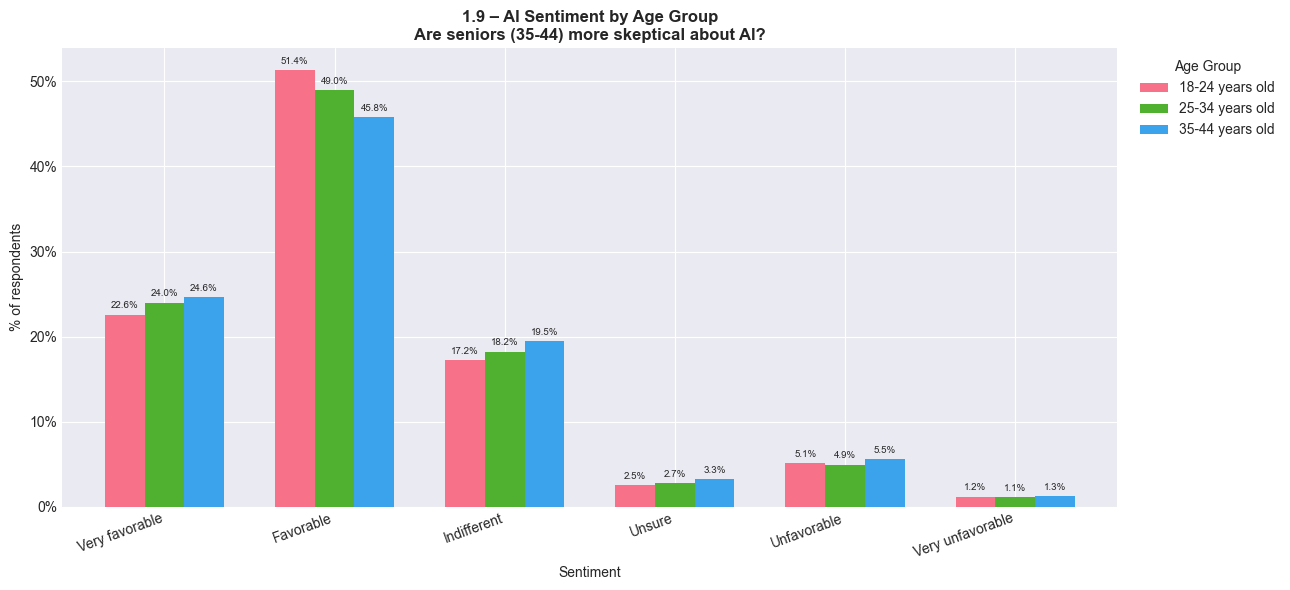


✅ Section 1.9 completed.


In [35]:
# ═══════════════════════════════════════════════════════════
# 📊 1.9 AI SKEPTICISM BY AGE – Are seniors more skeptical?
# ═══════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("📊 1.9 – AI SENTIMENT BY AGE (AISent)")
print("=" * 60)

sent_pivot = (
    df_ages.groupby(["Age", "AISent"])
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: x / x.sum() * 100, axis=1)
)

# Order sentiment from most to least favorable
sent_order = ["Very favorable", "Favorable", "Indifferent", "Unsure", "Unfavorable", "Very unfavorable"]
sent_order = [s for s in sent_order if s in sent_pivot.columns]
sent_pivot = sent_pivot[sent_order]

print(sent_pivot.round(1).to_string())

fig, ax = plt.subplots(figsize=(13, 6))
sent_pivot.T.plot(kind="bar", ax=ax, color=sns.color_palette("husl", 3), width=0.7)
ax.set_title("1.9 – AI Sentiment by Age Group\nAre seniors (35-44) more skeptical about AI?",
             fontweight="bold", fontsize=12)
ax.set_xlabel("Sentiment")
ax.set_ylabel("% of respondents")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.legend(title="Age Group", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=7, padding=3)

plt.tight_layout()
plt.show()
print("\n✅ Section 1.9 completed.")




📊 2.0 – AI THREAT PERCEPTION BY AGE (AIThreat)
AIThreat          Yes  I'm not sure    No
Age                                      
18-24 years old  13.0          23.5  63.4
25-34 years old  11.6          19.0  69.4
35-44 years old  12.0          19.2  68.8


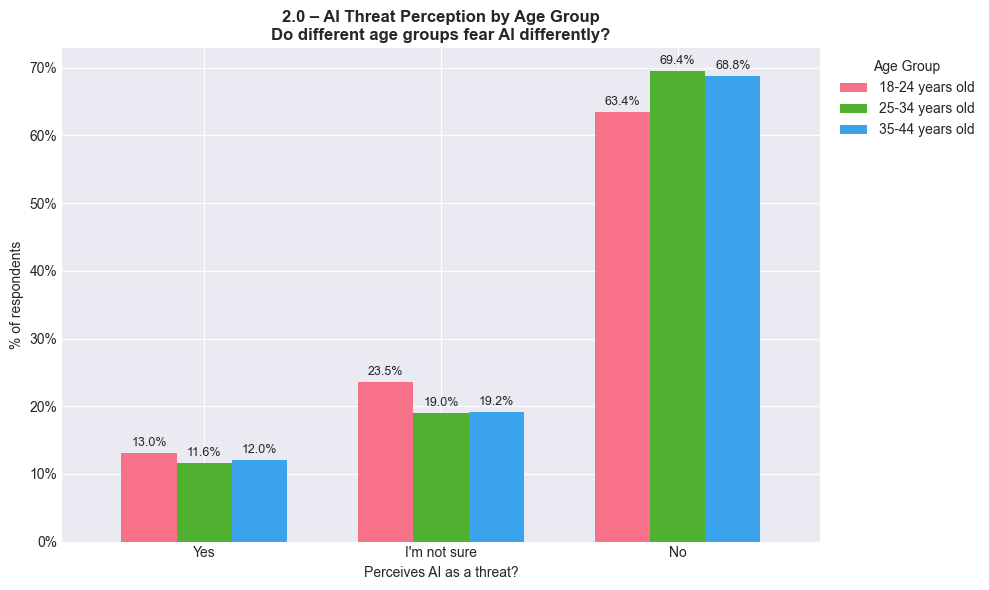


✅ Section 2.0 completed.


In [36]:
# ═══════════════════════════════════════════════════════════
# 📊 2.0 AI THREAT PERCEPTION BY AGE
# ═══════════════════════════════════════════════════════════

print("\n" + "=" * 60)
print("📊 2.0 – AI THREAT PERCEPTION BY AGE (AIThreat)")
print("=" * 60)

threat_pivot = (
    df_ages.groupby(["Age", "AIThreat"])
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: x / x.sum() * 100, axis=1)
)

# Order responses logically
threat_order = ["Yes", "I'm not sure", "No"]
threat_order = [t for t in threat_order if t in threat_pivot.columns]
threat_pivot = threat_pivot[threat_order]

print(threat_pivot.round(1).to_string())

fig, ax = plt.subplots(figsize=(10, 6))
threat_pivot.T.plot(kind="bar", ax=ax, color=sns.color_palette("husl", 3), width=0.7)
ax.set_title("2.0 – AI Threat Perception by Age Group\nDo different age groups fear AI differently?",
             fontweight="bold", fontsize=12)
ax.set_xlabel("Perceives AI as a threat?")
ax.set_ylabel("% of respondents")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Age Group", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=9, padding=3)

plt.tight_layout()
plt.show()
print("\n✅ Section 2.0 completed.")

📊 2.1 – AI ADOPTION & TRUST BY EXPERIENCE (YearsCode)
YearsCode unique values sample:
YearsCode
10    4561
5     3723
6     3496
8     3449
7     3333
4     3290
15    2813
20    2636
12    2559
3     2518

Experience group distribution:
ExperienceGroup
0-2 yrs       2354
3-5 yrs       9531
6-10 yrs     17090
11-20 yrs    17171
20+ yrs      12900


C:\Users\Usuario\AppData\Local\Temp\ipykernel_20500\1619277693.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["ExperienceGroup", "AISelect"])
C:\Users\Usuario\AppData\Local\Temp\ipykernel_20500\1619277693.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["ExperienceGroup", "AIAcc"])


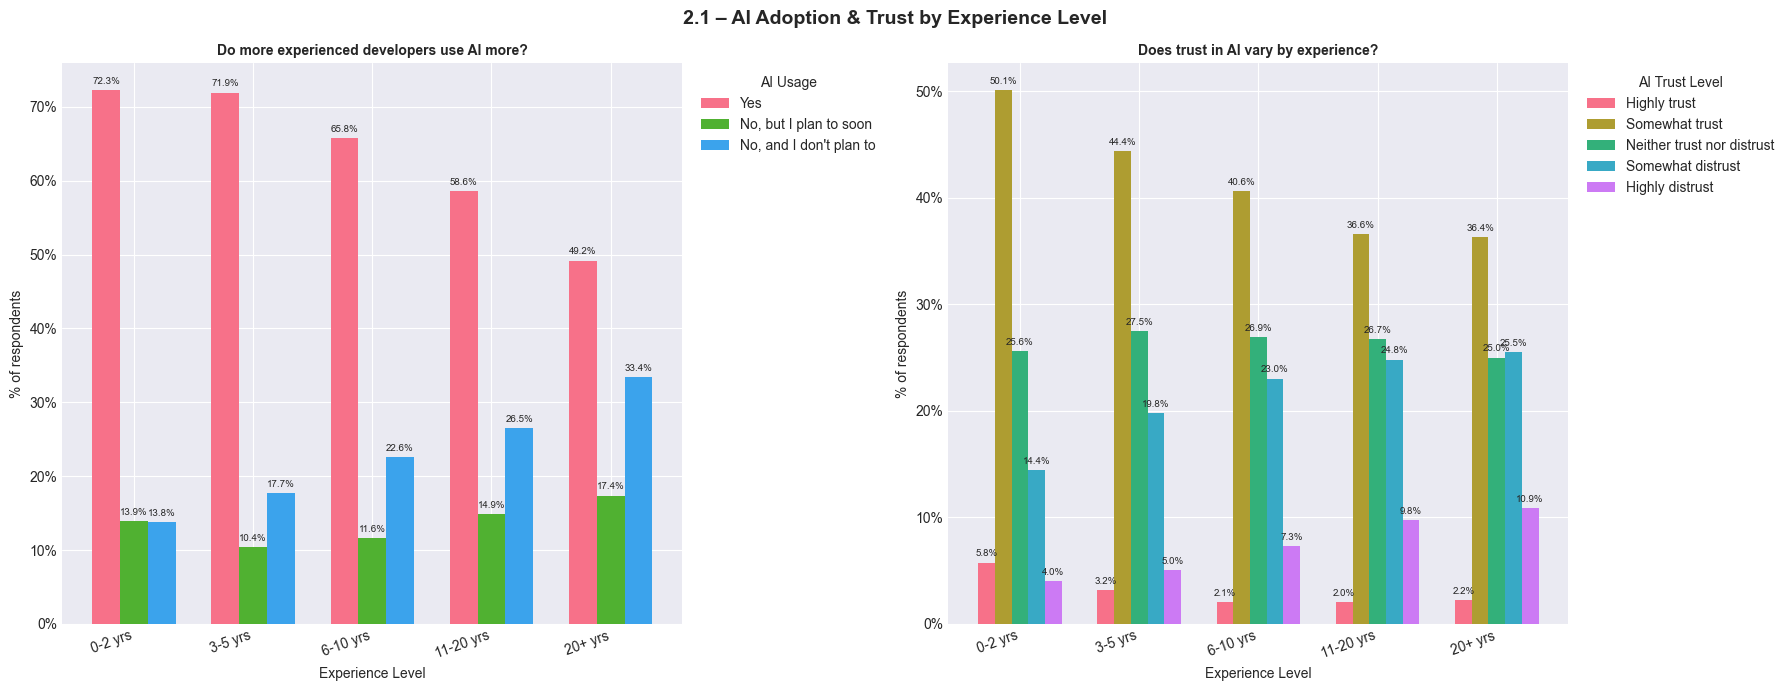


✅ Section 2.1 completed.


In [37]:
# ═══════════════════════════════════════════════════════════
# 📊 2.1 AI ADOPTION & TRUST BY EXPERIENCE (YearsCode)
# ═══════════════════════════════════════════════════════════

print("=" * 60)
print("📊 2.1 – AI ADOPTION & TRUST BY EXPERIENCE (YearsCode)")
print("=" * 60)

# ── Check unique values ──────────────────────────────────────
print("YearsCode unique values sample:")
print(df["YearsCode"].value_counts().head(10).to_string())

# ── Clean and bin YearsCode ──────────────────────────────────
df["YearsCode_clean"] = pd.to_numeric(df["YearsCode"], errors="coerce")

bins = [0, 2, 5, 10, 20, 100]
labels = ["0-2 yrs", "3-5 yrs", "6-10 yrs", "11-20 yrs", "20+ yrs"]
df["ExperienceGroup"] = pd.cut(df["YearsCode_clean"], bins=bins, labels=labels, right=True)

print("\nExperience group distribution:")
print(df["ExperienceGroup"].value_counts().sort_index().to_string())

# ── VISUALIZATION ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("2.1 – AI Adoption & Trust by Experience Level", fontsize=14, fontweight="bold")

# --- Chart 1: AISelect by ExperienceGroup ---
ax = axes[0]
adoption_exp = (
    df.groupby(["ExperienceGroup", "AISelect"])
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: x / x.sum() * 100, axis=1)
)

adoption_order = ["Yes", "No, but I plan to soon", "No, and I don't plan to"]
adoption_order = [a for a in adoption_order if a in adoption_exp.columns]
adoption_exp = adoption_exp[adoption_order]

adoption_exp.plot(kind="bar", ax=ax, color=sns.color_palette("husl", 3), width=0.7)
ax.set_title("Do more experienced developers use AI more?", fontweight="bold", fontsize=10)
ax.set_xlabel("Experience Level")
ax.set_ylabel("% of respondents")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.legend(title="AI Usage", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=7, padding=3)

# --- Chart 2: AIAcc by ExperienceGroup ---
ax = axes[1]
trust_exp = (
    df.groupby(["ExperienceGroup", "AIAcc"])
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: x / x.sum() * 100, axis=1)
)

trust_order = ["Highly trust", "Somewhat trust", "Neither trust nor distrust",
               "Somewhat distrust", "Highly distrust"]
trust_order = [t for t in trust_order if t in trust_exp.columns]
trust_exp = trust_exp[trust_order]

trust_exp.plot(kind="bar", ax=ax, color=sns.color_palette("husl", 5), width=0.7)
ax.set_title("Does trust in AI vary by experience?", fontweight="bold", fontsize=10)
ax.set_xlabel("Experience Level")
ax.set_ylabel("% of respondents")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.legend(title="AI Trust Level", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=7, padding=3)

plt.tight_layout()
plt.show()
print("\n✅ Section 2.1 completed.")

📊 2.2 – AI ADOPTION & SENTIMENT BY COUNTRY
Top 10 countries: ['United States of America', 'Germany', 'India', 'United Kingdom of Great Britain and Northern Ireland', 'Ukraine', 'France', 'Canada', 'Poland', 'Netherlands', 'Brazil']



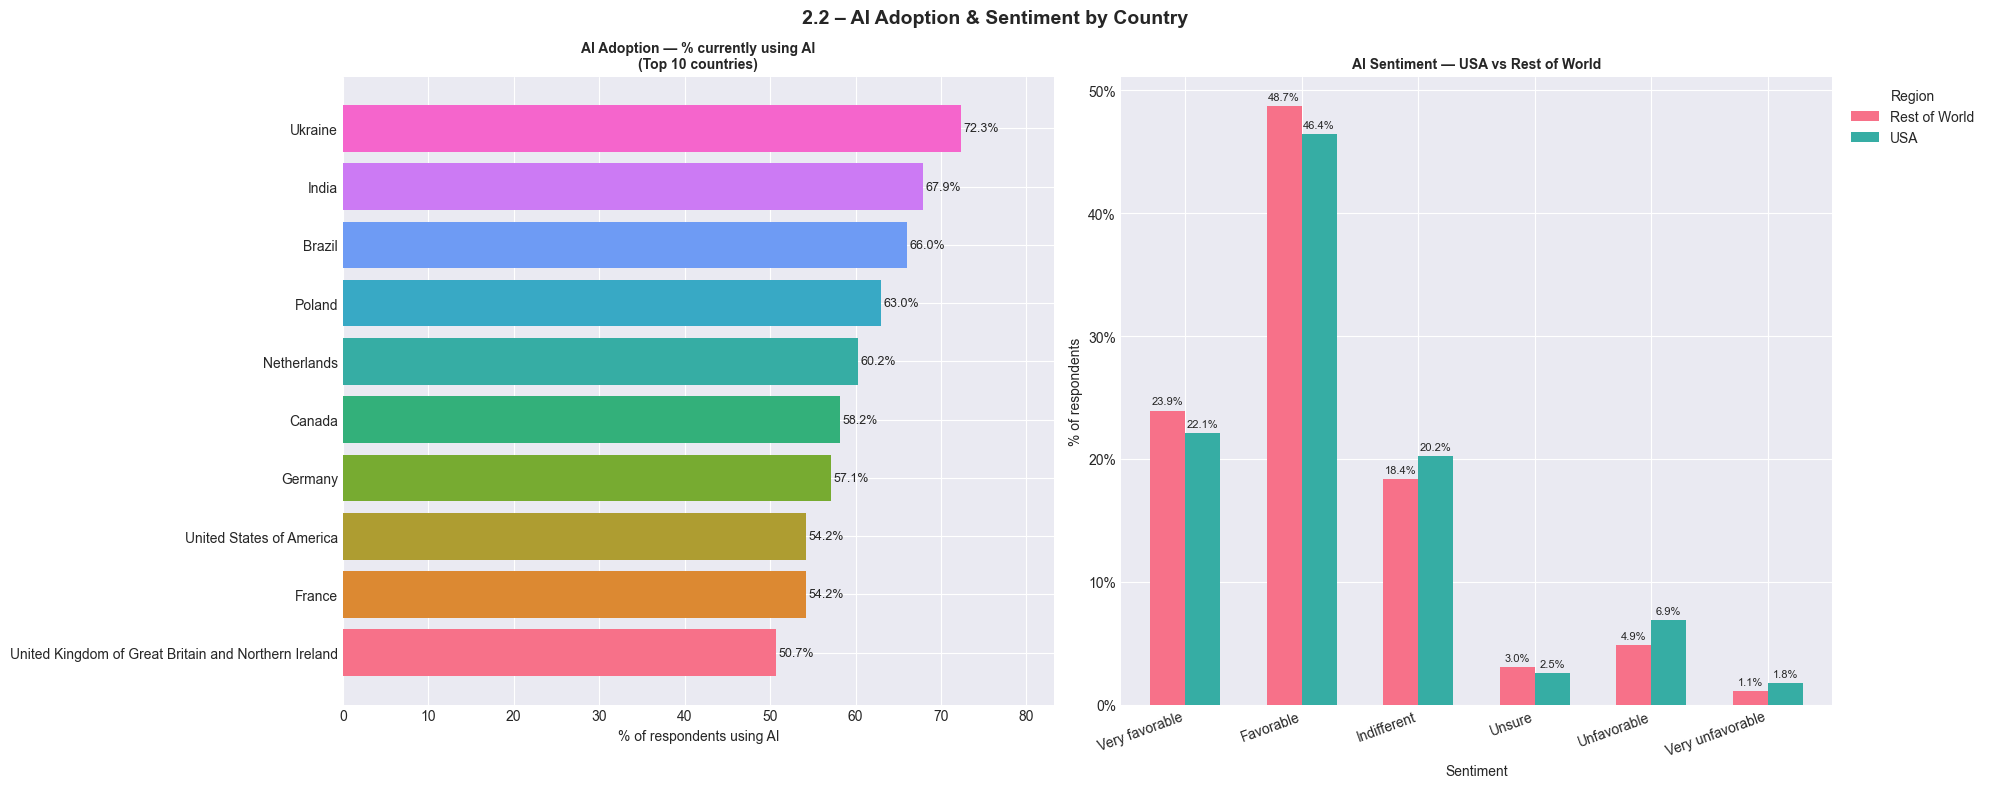


✅ Section 2.2 completed.


In [38]:
# ═══════════════════════════════════════════════════════════
# 📊 2.2 AI ADOPTION & SENTIMENT BY COUNTRY
# ═══════════════════════════════════════════════════════════

print("=" * 60)
print("📊 2.2 – AI ADOPTION & SENTIMENT BY COUNTRY")
print("=" * 60)

# ── Top 10 countries ─────────────────────────────────────────
top10_countries = df["Country"].value_counts().head(10).index.tolist()
df_top10 = df[df["Country"].isin(top10_countries)].copy()

print(f"Top 10 countries: {top10_countries}\n")

# ── VISUALIZATION ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("2.2 – AI Adoption & Sentiment by Country", fontsize=14, fontweight="bold")

# --- Chart 1: AISelect (Yes %) by Country ---
ax = axes[0]
adoption_country = (
    df_top10.groupby(["Country", "AISelect"])
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: x / x.sum() * 100, axis=1)
)

# Keep only "Yes" and sort
yes_pct = adoption_country["Yes"].sort_values(ascending=True)

bars = ax.barh(yes_pct.index, yes_pct.values,
               color=sns.color_palette("husl", len(yes_pct)))
ax.set_title("AI Adoption — % currently using AI\n(Top 10 countries)",
             fontweight="bold", fontsize=10)
ax.set_xlabel("% of respondents using AI")
ax.set_xlim(0, yes_pct.max() * 1.15)
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.1f}%", va="center", fontsize=9)

# --- Chart 2: USA vs Rest of World — AISent ---
ax = axes[1]
df["Region"] = df["Country"].apply(lambda x: "USA" if x == "United States of America" else "Rest of World")

sent_region = (
    df.groupby(["Region", "AISent"])
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: x / x.sum() * 100, axis=1)
)

sent_order = ["Very favorable", "Favorable", "Indifferent", "Unsure", "Unfavorable", "Very unfavorable"]
sent_order = [s for s in sent_order if s in sent_region.columns]
sent_region = sent_region[sent_order]

sent_region.T.plot(kind="bar", ax=ax, color=sns.color_palette("husl", 2), width=0.6)
ax.set_title("AI Sentiment — USA vs Rest of World",
             fontweight="bold", fontsize=10)
ax.set_xlabel("Sentiment")
ax.set_ylabel("% of respondents")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.legend(title="Region", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=8, padding=3)

plt.tight_layout()
plt.show()
print("\n✅ Section 2.2 completed.")

📊 2.3 – AI ADOPTION & SENTIMENT BY DEVELOPER TYPE
Top 10 developer roles:
DevType
Developer, full-stack                            18260
Developer, back-end                               9928
Student                                           5102
Developer, front-end                              3349
Developer, desktop or enterprise applications     2493
Other (please specify):                           2458
Developer, mobile                                 2021
Developer, embedded applications or devices       1623
Engineering manager                               1275
Academic researcher                               1238


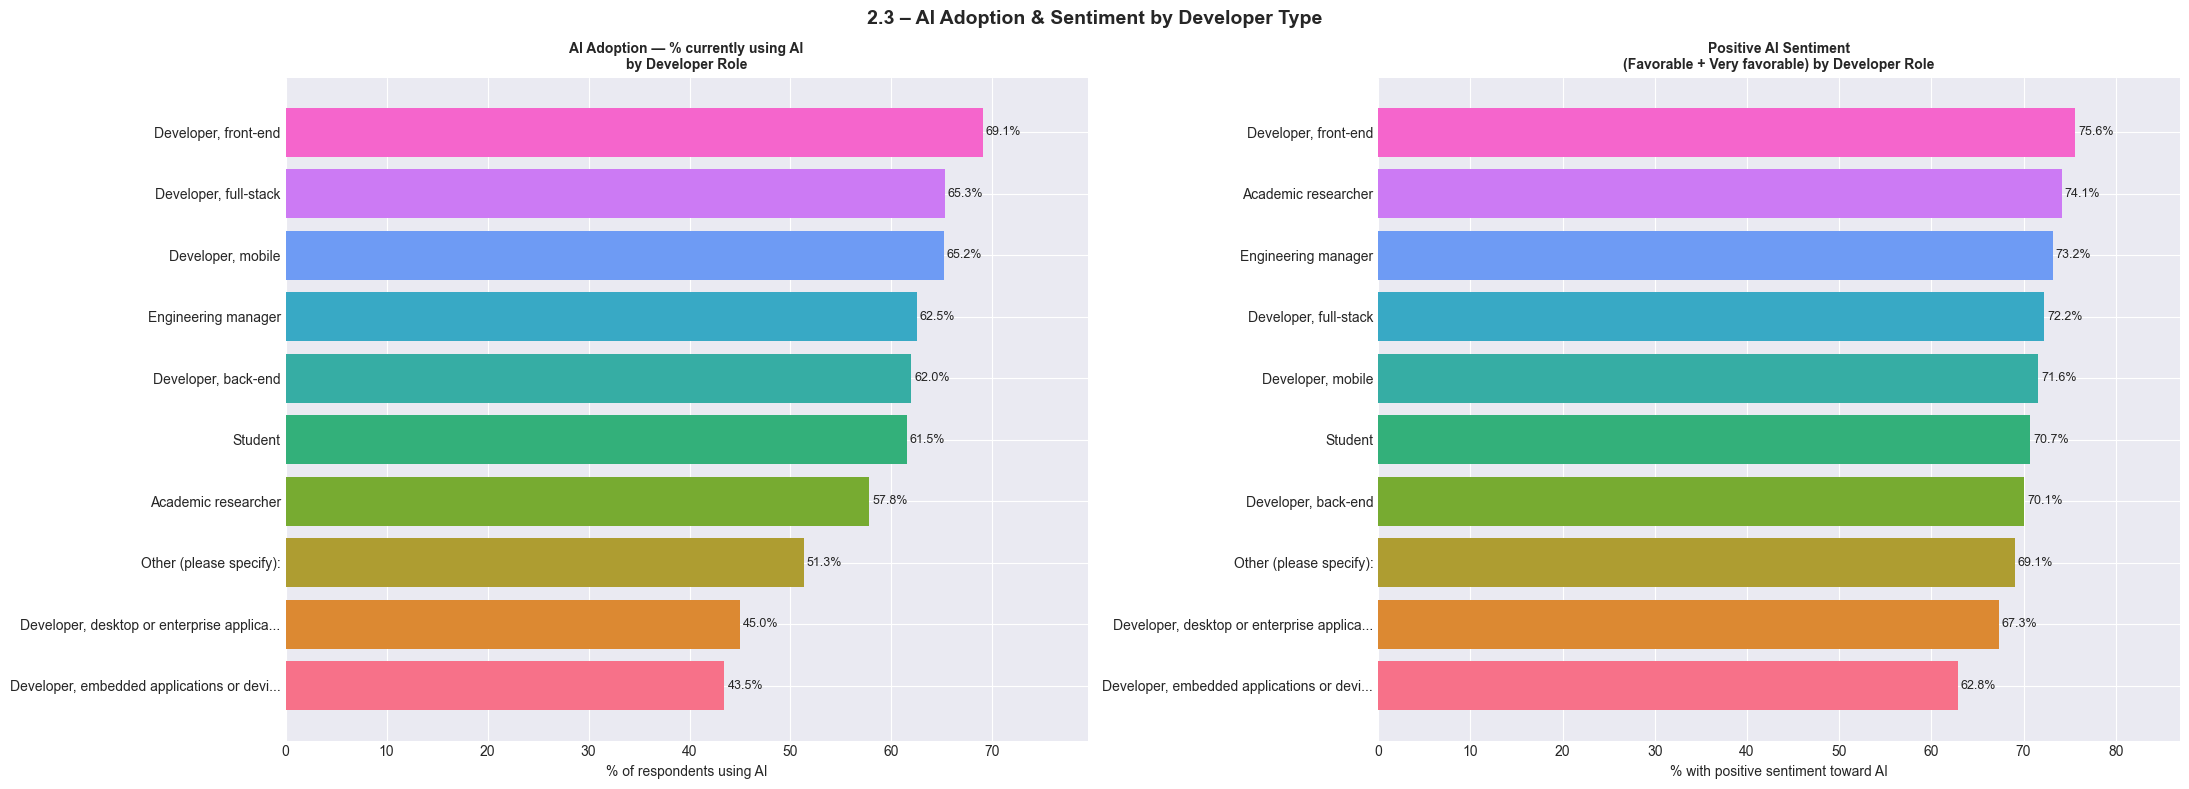


✅ Section 2.3 completed.


In [39]:
# ═══════════════════════════════════════════════════════════
# 📊 2.3 AI ADOPTION & SENTIMENT BY DEVELOPER TYPE
# ═══════════════════════════════════════════════════════════

print("=" * 60)
print("📊 2.3 – AI ADOPTION & SENTIMENT BY DEVELOPER TYPE")
print("=" * 60)

# ── Explode DevType (multi-response column) ──────────────────
df_devtype = (
    df[["DevType", "AISelect", "AISent"]]
    .dropna(subset=["DevType"])
    .copy()
)
df_devtype = df_devtype.assign(
    DevType=df_devtype["DevType"].str.split(";")
).explode("DevType")
df_devtype["DevType"] = df_devtype["DevType"].str.strip()

# Keep top 10 most common roles
top10_roles = df_devtype["DevType"].value_counts().head(10).index.tolist()
df_devtype = df_devtype[df_devtype["DevType"].isin(top10_roles)]

print("Top 10 developer roles:")
print(df_devtype["DevType"].value_counts().to_string())

# ── VISUALIZATION ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(22, 8))
fig.suptitle("2.3 – AI Adoption & Sentiment by Developer Type", fontsize=14, fontweight="bold")

# --- Chart 1: AISelect (Yes %) by DevType ---
ax = axes[0]
adoption_dev = (
    df_devtype.groupby(["DevType", "AISelect"])
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: x / x.sum() * 100, axis=1)
)

yes_pct = adoption_dev["Yes"].sort_values(ascending=True)

# Truncate long labels
labels = [l[:40] + "..." if len(l) > 40 else l for l in yes_pct.index]

bars = ax.barh(labels, yes_pct.values, color=sns.color_palette("husl", len(yes_pct)))
ax.set_title("AI Adoption — % currently using AI\nby Developer Role",
             fontweight="bold", fontsize=10)
ax.set_xlabel("% of respondents using AI")
ax.set_xlim(0, yes_pct.max() * 1.15)
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.1f}%", va="center", fontsize=9)

# --- Chart 2: Favorable + Very favorable % by DevType ---
ax = axes[1]
sent_dev = (
    df_devtype.groupby(["DevType", "AISent"])
    .size()
    .unstack(fill_value=0)
    .apply(lambda x: x / x.sum() * 100, axis=1)
)

# Combine favorable + very favorable
sent_dev["Positive sentiment"] = (
    sent_dev.get("Favorable", 0) + sent_dev.get("Very favorable", 0)
)
positive_pct = sent_dev["Positive sentiment"].sort_values(ascending=True)

labels2 = [l[:40] + "..." if len(l) > 40 else l for l in positive_pct.index]

bars = ax.barh(labels2, positive_pct.values, color=sns.color_palette("husl", len(positive_pct)))
ax.set_title("Positive AI Sentiment\n(Favorable + Very favorable) by Developer Role",
             fontweight="bold", fontsize=10)
ax.set_xlabel("% with positive sentiment toward AI")
ax.set_xlim(0, positive_pct.max() * 1.15)
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()
print("\n✅ Section 2.3 completed.")

---

## 📝 Initial EDA — Key Findings

### 🔍 Dataset Overview

The Stack Overflow Developer Survey 2024 includes **65,437 respondents** across **114 variables**, covering AI adoption, professional experience, demographics, and compensation.

| **Metric** | **Value** |
|------------|-----------|
| Total respondents | 65,437 |
| Total variables | 114 |
| Countries represented | 185+ |
| AI-related variables | 5 (AISelect, AISent, AIBen, AIThreat, AIAcc) |
| Overall data completeness | ~74% |

### 🎯 Data Quality

- Missing values are concentrated in optional/multi-response columns (AINext, Embedded, Knowledge)
- Core analysis variables (AISelect, AISent, DevType, YearsCode, Country) have high completion rates
- No significant duplicate responses detected

### 🚀 Key Variables for Analysis

- **AI Adoption**: AISelect, AISent, AIBen, AIThreat, AIAcc
- **Professional context**: DevType, YearsCode, OrgSize, Employment
- **Demographics**: Country, Age, EdLevel

---

## 📊 EDA Summary — Key Findings

### 1. AI Adoption is already mainstream
Over **62% of developers** are actively using AI tools. Adoption is not a niche behavior — it's the norm across all roles and experience levels.

### 2. Younger developers adopt AI more, but seniors are catching up
Adoption drops from **72.3% (0-2 yrs)** to **49.2% (20+ yrs)**. However, the "No, but I plan to soon" group grows with experience, suggesting seniors are aware and moving toward adoption.

### 3. Experience increases skepticism toward AI accuracy
Junior developers show **50.1% "Somewhat trust"** vs **36.4%** in the 20+ group. More experienced developers are better equipped to detect AI errors — and do.

### 4. Age has little impact on fear of AI
Across the 3 largest age groups, only **11-13% see AI as a threat**. The main differentiator is uncertainty — younger developers are less sure, not more afraid.

### 5. Emerging markets lead AI adoption
Ukraine (72.3%), India (67.9%) and Brazil (66.0%) outpace USA (54.2%) and UK (50.7%) in adoption. Market size does not predict AI enthusiasm.

### 6. Front-end developers are the most enthusiastic adopters
With **69.1% adoption** and **75.6% positive sentiment**, front-end roles lead — likely because AI delivers immediate, visible value in UI/code generation tasks.

---

## 🤖 Predictive Modeling — Will a Developer Use AI?

### 🎯 Objective

Based on the patterns uncovered in the EDA, we now build a classification model to predict whether a developer currently uses AI tools (`AISelect` = Yes/No).

This transforms our exploratory findings into a predictive framework: given a developer's profile (age, experience, role, country, education), can we predict their likelihood of adopting AI?


### 🔧 Approach

We train and compare two models:

| **Model** | **Why** |
|-----------|---------|
| Logistic Regression | Simple, interpretable baseline. Shows which features push toward adoption. |
| Random Forest | Higher accuracy, handles non-linear relationships, provides feature importance. |

### 📥 Features used for prediction

| **Feature** | **Type** | **Rationale** |
|-------------|----------|---------------|
| `Age` | Categorical | Younger developers show higher adoption rates |
| `YearsCode` | Numerical | Experience level inversely correlated with adoption |
| `DevType` | Categorical | Role type significantly impacts AI usage |
| `Country` | Categorical | Geographic differences observed in adoption |
| `EdLevel` | Categorical | Education level may influence AI familiarity |
| `OrgSize` | Categorical | Company size may affect AI tool availability |

### 🎯 Target Variable

`AISelect` → Binary classification:
- **1** = Yes (currently using AI)
- **0** = No (not using AI — combining "No, and I don't plan to" + "No, but I plan to soon")

### 📊 Evaluation Metrics

- **Accuracy**: Overall correct predictions
- **Precision & Recall**: Balance between false positives and false negatives
- **F1 Score**: Harmonic mean of precision and recall
- **ROC-AUC**: Model's ability to distinguish between classes

---

In [40]:
# ═══════════════════════════════════════════════════════════
# 🤖 3.1 DATA PREPARATION FOR MODELING
# ═══════════════════════════════════════════════════════════

print("=" * 60)
print("🤖 3.1 – DATA PREPARATION FOR MODELING")
print("=" * 60)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             ConfusionMatrixDisplay)

# ── Define features and target ───────────────────────────────
features = ["Age", "YearsCode", "DevType", "Country", "EdLevel", "OrgSize"]
target = "AISelect"

# ── Build modeling dataframe ─────────────────────────────────
df_model = df[features + [target]].copy()

# ── Simplify DevType (take first role only) ──────────────────
df_model["DevType"] = df_model["DevType"].str.split(";").str[0].str.strip()

# ── Simplify Country (top 15 + "Other") ─────────────────────
top15 = df["Country"].value_counts().head(15).index.tolist()
df_model["Country"] = df_model["Country"].apply(lambda x: x if x in top15 else "Other")

# ── Binarize target ──────────────────────────────────────────
df_model = df_model[df_model[target].notna()]
df_model["target"] = (df_model[target] == "Yes").astype(int)

# ── Drop rows with missing values ────────────────────────────
df_model = df_model.dropna()

print(f"Modeling dataset shape: {df_model.shape}")
print(f"Target distribution:\n{df_model['target'].value_counts(normalize=True).round(3) * 100}")

# ── Encode categorical variables ────────────────────────────
cat_cols = ["Age", "DevType", "Country", "EdLevel", "OrgSize"]
df_encoded = df_model.copy()

le = LabelEncoder()
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

df_encoded["YearsCode"] = pd.to_numeric(df_encoded["YearsCode"], errors="coerce")
df_encoded = df_encoded.dropna(subset=["YearsCode"])

X = df_encoded[features]
y = df_encoded["target"]

# ── Train/test split ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {X_train.shape[0]:,} | Test size: {X_test.shape[0]:,}")
print("\n✅ Data preparation completed.")

🤖 3.1 – DATA PREPARATION FOR MODELING
Modeling dataset shape: (46145, 8)
Target distribution:
target
1    61.8
0    38.2
Name: proportion, dtype: float64

Train size: 36,776 | Test size: 9,195

✅ Data preparation completed.


🤖 3.2 – MODEL TRAINING & EVALUATION

📊 Logistic Regression
  Accuracy:  0.589
  Precision: 0.670
  Recall:    0.664
  F1 Score:  0.667
  ROC-AUC:   0.602

              precision    recall  f1-score   support

       No AI       0.46      0.47      0.47      3505
     Uses AI       0.67      0.66      0.67      5690

    accuracy                           0.59      9195
   macro avg       0.57      0.57      0.57      9195
weighted avg       0.59      0.59      0.59      9195


📊 Random Forest
  Accuracy:  0.584
  Precision: 0.650
  Recall:    0.710
  F1 Score:  0.679
  ROC-AUC:   0.569

              precision    recall  f1-score   support

       No AI       0.45      0.38      0.41      3505
     Uses AI       0.65      0.71      0.68      5690

    accuracy                           0.58      9195
   macro avg       0.55      0.54      0.54      9195
weighted avg       0.57      0.58      0.58      9195



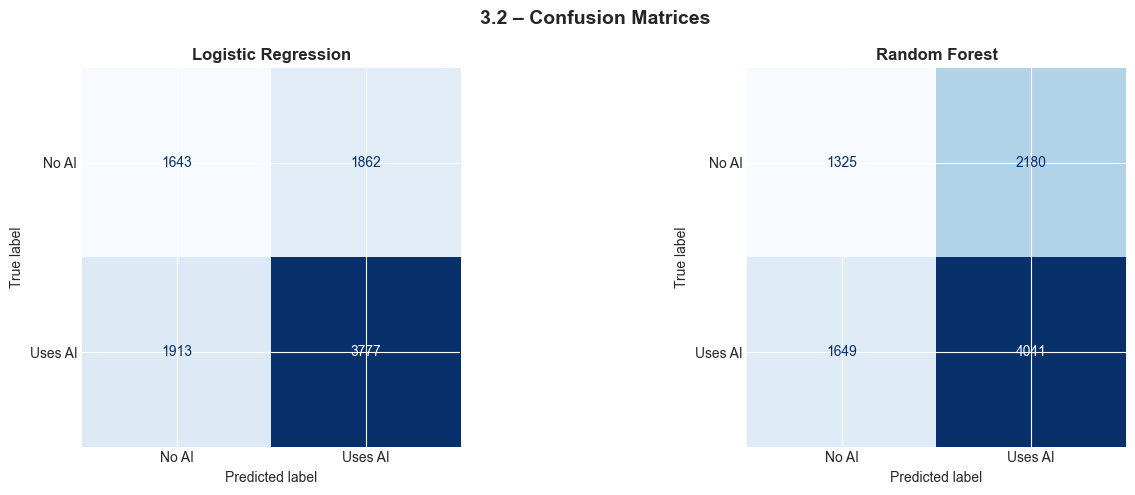

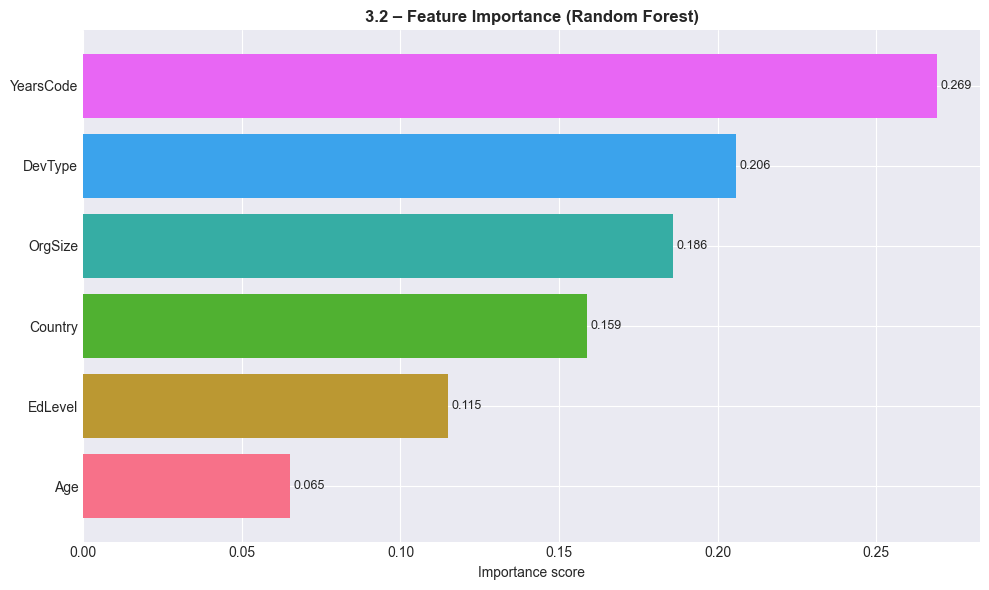


✅ Section 3.2 completed.


In [41]:
# ═══════════════════════════════════════════════════════════
# 🤖 3.2 MODEL TRAINING & EVALUATION
# ═══════════════════════════════════════════════════════════

print("=" * 60)
print("🤖 3.2 – MODEL TRAINING & EVALUATION")
print("=" * 60)

# ── Train models ─────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

# ── Evaluate ─────────────────────────────────────────────────
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(f"\n{'=' * 60}")
    print(f"📊 {name}")
    print(f"{'=' * 60}")
    print(f"  Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
    print(f"  Precision: {precision_score(y_test, y_pred):.3f}")
    print(f"  Recall:    {recall_score(y_test, y_pred):.3f}")
    print(f"  F1 Score:  {f1_score(y_test, y_pred):.3f}")
    print(f"  ROC-AUC:   {roc_auc_score(y_test, y_prob):.3f}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['No AI', 'Uses AI'])}")
    return y_pred, y_prob

lr_pred, lr_prob = evaluate_model("Logistic Regression", lr, X_test, y_test)
rf_pred, rf_prob = evaluate_model("Random Forest", rf, X_test, y_test)

# ── Confusion matrices ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("3.2 – Confusion Matrices", fontsize=14, fontweight="bold")

for ax, model, pred, name in zip(axes,
                                  [lr, rf],
                                  [lr_pred, rf_pred],
                                  ["Logistic Regression", "Random Forest"]):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred,
        display_labels=["No AI", "Uses AI"],
        colorbar=False,
        ax=ax,
        cmap="Blues"
    )
    ax.set_title(name, fontweight="bold")

plt.tight_layout()
plt.show()

# ── Feature importance (Random Forest) ──────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
importances = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)
bars = ax.barh(importances.index, importances.values, color=sns.color_palette("husl", len(features)))
ax.set_title("3.2 – Feature Importance (Random Forest)", fontweight="bold", fontsize=12)
ax.set_xlabel("Importance score")
for bar in bars:
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print("\n✅ Section 3.2 completed.")

### 📋 Model Performance — Initial Results

Both models achieve ~58-59% accuracy and ROC-AUC scores between 0.57–0.60, which is above random baseline (50%) but indicates limited predictive power.

**Key observation:** Demographic and professional profile variables alone are not strong predictors of AI adoption. The EDA already hinted at this — differences between groups were real but moderate. This suggests AI adoption is a cross-cutting behavior not strongly determined by age, role, or experience.

**This is itself a finding:** who you are matters less than we expected for predicting AI adoption.

### 🔧 Next Steps — Model Improvement (Section 3.3)

To improve performance we will explore:
1. **Richer features** — adding behavioral variables (languages used, remote work, professional experience)
2. **Better encoding** — replacing LabelEncoder with OneHotEncoder for categorical variables
3. **Hyperparameter tuning** — optimizing Random Forest parameters
4. **XGBoost** — a more powerful algorithm for tabular data

---

🔧 3.3 – MODEL IMPROVEMENT
Modeling dataset v2 shape: (44198, 10)
Target distribution:
target
1    61.6
0    38.4
Name: proportion, dtype: float64

📊 Logistic Regression v2
  Accuracy    : 0.600
  Precision   : 0.694
  Recall      : 0.628
  F1          : 0.659
  ROC-AUC     : 0.638

📊 Random Forest v2
  Accuracy    : 0.589
  Precision   : 0.702
  Recall      : 0.579
  F1          : 0.634
  ROC-AUC     : 0.628

📊 XGBoost
  Accuracy    : 0.596
  Precision   : 0.703
  Recall      : 0.594
  F1          : 0.644
  ROC-AUC     : 0.633

📋 MODEL COMPARISON
                        Accuracy  Precision  Recall     F1  ROC-AUC
Logistic Regression v2     0.600      0.694   0.628  0.659    0.638
Random Forest v2           0.589      0.702   0.579  0.634    0.628
XGBoost                    0.596      0.703   0.594  0.644    0.633


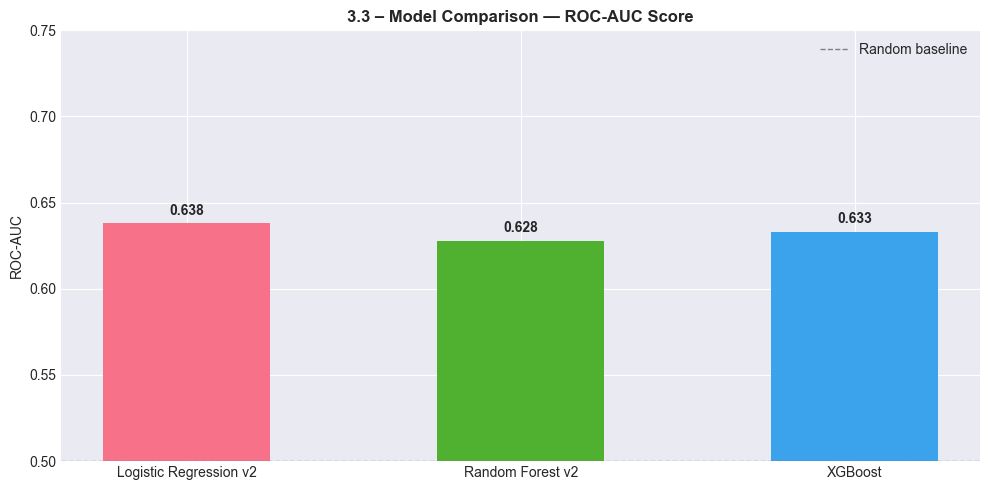


✅ Section 3.3 completed.


In [42]:
# ═══════════════════════════════════════════════════════════
# 🔧 3.3 MODEL IMPROVEMENT
# ═══════════════════════════════════════════════════════════

print("=" * 60)
print("🔧 3.3 – MODEL IMPROVEMENT")
print("=" * 60)

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
import xgboost as xgb

# ── Richer feature set ───────────────────────────────────────
features_v2 = ["Age", "YearsCode", "YearsCodePro", "DevType",
               "Country", "EdLevel", "OrgSize", "RemoteWork"]

df_model_v2 = df[features_v2 + [target]].copy()

# ── Simplify multi-response columns ─────────────────────────
df_model_v2["DevType"] = df_model_v2["DevType"].str.split(";").str[0].str.strip()
df_model_v2["Country"] = df_model_v2["Country"].apply(lambda x: x if x in top15 else "Other")

# ── Binarize target ──────────────────────────────────────────
df_model_v2 = df_model_v2[df_model_v2[target].notna()]
df_model_v2["target"] = (df_model_v2[target] == "Yes").astype(int)
df_model_v2 = df_model_v2.dropna()

# ── Numeric and categorical columns ─────────────────────────
num_cols = ["YearsCode", "YearsCodePro"]
cat_cols_v2 = ["Age", "DevType", "Country", "EdLevel", "OrgSize", "RemoteWork"]

# Convert numeric cols
for col in num_cols:
    df_model_v2[col] = pd.to_numeric(df_model_v2[col], errors="coerce")
df_model_v2 = df_model_v2.dropna(subset=num_cols)

print(f"Modeling dataset v2 shape: {df_model_v2.shape}")
print(f"Target distribution:\n{df_model_v2['target'].value_counts(normalize=True).round(3) * 100}")

X_v2 = df_model_v2[features_v2]
y_v2 = df_model_v2["target"]

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42, stratify=y_v2
)

# ── Preprocessor with OneHotEncoder ─────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ("num", "passthrough", num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols_v2)
])

# ── Pipelines ────────────────────────────────────────────────
pipe_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42))
])

pipe_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(n_estimators=200, max_depth=10,
                                      class_weight="balanced", random_state=42, n_jobs=-1))
])

pipe_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                  scale_pos_weight=38/62, random_state=42,
                                  eval_metric="logloss", verbosity=0))
])

# ── Train & evaluate all models ──────────────────────────────
models_v2 = {
    "Logistic Regression v2": pipe_lr,
    "Random Forest v2": pipe_rf,
    "XGBoost": pipe_xgb
}

results = {}
for name, pipe in models_v2.items():
    pipe.fit(X_train_v2, y_train_v2)
    y_pred = pipe.predict(X_test_v2)
    y_prob = pipe.predict_proba(X_test_v2)[:, 1]
    results[name] = {
        "Accuracy":  accuracy_score(y_test_v2, y_pred),
        "Precision": precision_score(y_test_v2, y_pred),
        "Recall":    recall_score(y_test_v2, y_pred),
        "F1":        f1_score(y_test_v2, y_pred),
        "ROC-AUC":   roc_auc_score(y_test_v2, y_prob)
    }
    print(f"\n{'=' * 60}")
    print(f"📊 {name}")
    print(f"{'=' * 60}")
    for metric, val in results[name].items():
        print(f"  {metric:<12}: {val:.3f}")

# ── Comparison table ─────────────────────────────────────────
print("\n" + "=" * 60)
print("📋 MODEL COMPARISON")
print("=" * 60)
results_df = pd.DataFrame(results).T.round(3)
print(results_df.to_string())

# ── Visualization: ROC-AUC comparison ───────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette("husl", len(results))
bars = ax.bar(results_df.index, results_df["ROC-AUC"],
              color=colors, width=0.5)
ax.set_title("3.3 – Model Comparison — ROC-AUC Score", fontweight="bold", fontsize=12)
ax.set_ylabel("ROC-AUC")
ax.set_ylim(0.5, 0.75)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Random baseline")
ax.legend()
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n✅ Section 3.3 completed.")

---

## 📋 3.3 — Model Improvement Results

### 📊 Final Comparison

| **Model** | **Accuracy** | **Precision** | **Recall** | **F1** | **ROC-AUC** |
|-----------|-------------|--------------|-----------|--------|------------|
| Logistic Regression v1 | 0.589 | 0.670 | 0.664 | 0.667 | 0.602 |
| Random Forest v1 | 0.584 | 0.650 | 0.710 | 0.679 | 0.569 |
| **Logistic Regression v2** | **0.600** | **0.694** | **0.628** | **0.659** | **0.638** |
| Random Forest v2 | 0.589 | 0.702 | 0.579 | 0.634 | 0.628 |
| XGBoost | 0.596 | 0.703 | 0.594 | 0.644 | 0.633 |

### 🏆 Best Model: Logistic Regression v2

ROC-AUC improved from **0.602 → 0.638** (+6%) by:
- Adding behavioral features (`YearsCodePro`, `RemoteWork`)
- Replacing `LabelEncoder` with `OneHotEncoder`

### 🔍 Key Takeaways

**1. Profile alone has limited predictive power.**
A ROC-AUC of 0.638 means the model is better than random, but demographic and professional variables are not strong determinants of AI adoption. The decision to use AI is influenced by factors this dataset doesn't fully capture — individual curiosity, team culture, tool availability.

**2. Logistic Regression outperforms complex models.**
XGBoost and Random Forest did not add value over a simple linear model. This confirms the relationship between features and AI adoption is largely linear — no hidden complex patterns to exploit.

**3. High precision (0.694) with moderate recall (0.628).**
The model is better at confirming adopters than identifying all of them. It avoids false positives but misses some true adopters.

### 💡 To push performance further
- Include attitudinal variables (`AISent`, `AIAcc`) as features
- Add language stack as a behavioral signal
- Explore ensemble stacking

---

---

## 🎯 Final Conclusions

### What did we set out to answer?
This project analyzed the **Stack Overflow Developer Survey 2024** to understand how technology professionals adopt AI tools, and whether that adoption can be predicted from their profile.

---

### 🔍 What the data told us

**AI adoption is mainstream, not a trend.**
Over 62% of developers actively use AI tools today. Across all roles, countries, and experience levels, adoption is the norm — not the exception.

**Younger and less experienced developers lead adoption.**
Developers with 0-2 years of experience show 72.3% adoption vs 49.2% for those with 20+ years. But the gap is closing — senior developers increasingly plan to adopt.

**Experience breeds skepticism, not rejection.**
More experienced developers trust AI less (50.1% → 36.4% "Somewhat trust" from junior to senior). They use AI less, but not because they fear it — because they have more criteria to evaluate its limitations.

**AI is not seen as a job threat.**
Only 11-13% of developers across age groups consider AI a threat to their role. Fear of AI displacement is a media narrative more than a developer reality.

**Geography surprises: emerging markets lead.**
Ukraine (72.3%), India (67.9%) and Brazil (66.0%) outpace USA (54.2%) and UK (50.7%). Market size and tech maturity do not predict AI enthusiasm.

**Front-end developers are the most enthusiastic.**
With 69.1% adoption and 75.6% positive sentiment, front-end roles lead — AI delivers immediate, visible value in UI and code generation tasks.

---

### 🤖 What the model told us

The best model (**Logistic Regression v2**) achieved a ROC-AUC of **0.638** — better than random, but modest.

This is itself a meaningful finding: **a developer's profile is not a strong predictor of AI adoption.** The decision to use AI is driven more by individual curiosity, team culture, and tool availability than by age, role, or years of experience.

---

### 📌 Key Takeaway

> AI adoption in 2024 is broad, positive, and largely independent of developer profile. The question is no longer *who* uses AI — it's *how well* they use it.

---

*Dataset: Stack Overflow Developer Survey 2024 — 65,437 respondents, 114 variables.*
*Author: Diego Acosta | [LinkedIn](https://www.linkedin.com/in/diego-omar-acosta) | [GitHub](https://github.com/dieeacosta)*

---